In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [2]:
# Load the dataset
df = pd.read_csv('Uber-Jan-Feb-FOIL.csv')
# Display the first few rows of the dataset
df.head()

,dispatching_base_number,date,active_vehicles,trips
0,B02512,1/1/2015,190,1132
1,B02765,1/1/2015,225,1765
2,B02764,1/1/2015,3427,29421
3,B02682,1/1/2015,945,7679
4,B02617,1/1/2015,1228,9537


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354 entries, 0 to 353
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   dispatching_base_number  354 non-null    object
 1   date                     354 non-null    object
 2   active_vehicles          354 non-null    int64 
 3   trips                    354 non-null    int64 
dtypes: int64(2), object(2)
memory usage: 11.2+ KB


In [4]:
df.shape

(354, 4)

In [5]:
df.describe()

,active_vehicles,trips
count,354.000000,354.000000
mean,1307.435028,11667.316384
std,1162.510626,10648.284865
min,112.000000,629.000000
25%,296.750000,2408.500000
50%,1077.000000,9601.000000
75%,1417.000000,13711.250000
max,4395.000000,45858.000000


In [6]:
# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'])

# Extract features
df['day_of_week'] = df['date'].dt.day_name()
df['is_weekend'] = df['day_of_week'].isin(['Saturday', 'Sunday'])
df['month'] = df['date'].dt.month_name()
df['week_number'] = df['date'].dt.isocalendar().week

df.head()

,dispatching_base_number,date,active_vehicles,trips,day_of_week,is_weekend,month,week_number
0,B02512,2015-01-01,190,1132,Thursday,False,January,1
1,B02765,2015-01-01,225,1765,Thursday,False,January,1
2,B02764,2015-01-01,3427,29421,Thursday,False,January,1
3,B02682,2015-01-01,945,7679,Thursday,False,January,1
4,B02617,2015-01-01,1228,9537,Thursday,False,January,1


In [7]:
# Check for missing values
print(df.isnull().sum())

dispatching_base_number    0
date                       0
active_vehicles            0
trips                      0
day_of_week                0
is_weekend                 0
month                      0
week_number                0
dtype: int64


In [8]:
# Check for duplicates
print(f"Duplicates found: {df.duplicated().sum()}")

Duplicates found: 0


In [9]:
# Aggregate total trips per day
daily_trips = df.groupby('date')['trips'].sum().reset_index()

In [10]:
daily_trips.head()

,date,trips
0,2015-01-01,56437
1,2015-01-02,39189
2,2015-01-03,58449
3,2015-01-04,40798
4,2015-01-05,42752


## Visualisation

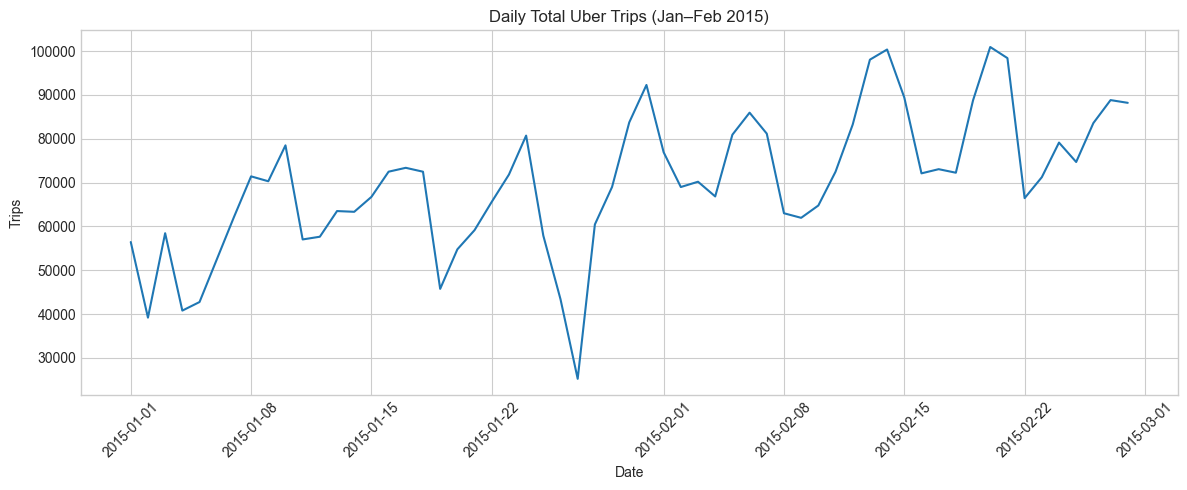

In [11]:
# Daily total trips
plt.figure(figsize=(12, 5))
sns.lineplot(data=daily_trips, x='date', y='trips')
plt.title('Daily Total Uber Trips (Jan–Feb 2015)')
plt.xlabel('Date')
plt.ylabel('Trips')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

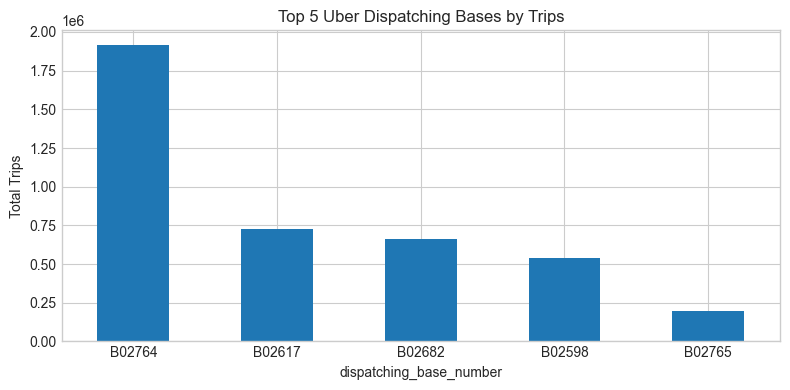

In [12]:
# Top 5 dispatch bases
top_bases = df.groupby('dispatching_base_number')['trips'].sum().sort_values(ascending=False).head(5)
top_bases.plot(kind='bar', figsize=(8, 4), title='Top 5 Uber Dispatching Bases by Trips')
plt.ylabel('Total Trips')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


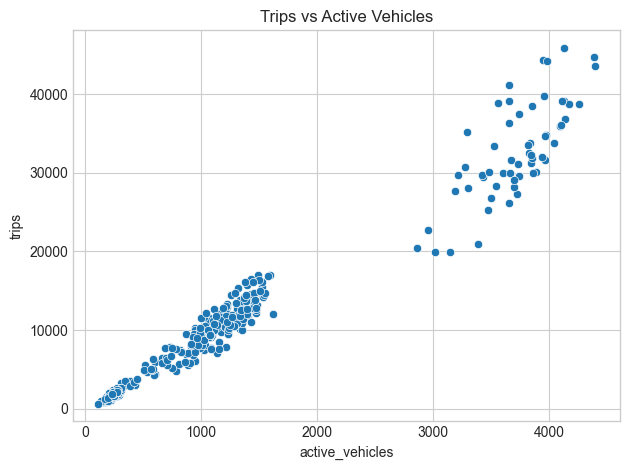

In [13]:
# Correlation: active vehicles vs trips
sns.scatterplot(data=df, x='active_vehicles', y='trips')
plt.title('Trips vs Active Vehicles')
plt.tight_layout()
plt.show()



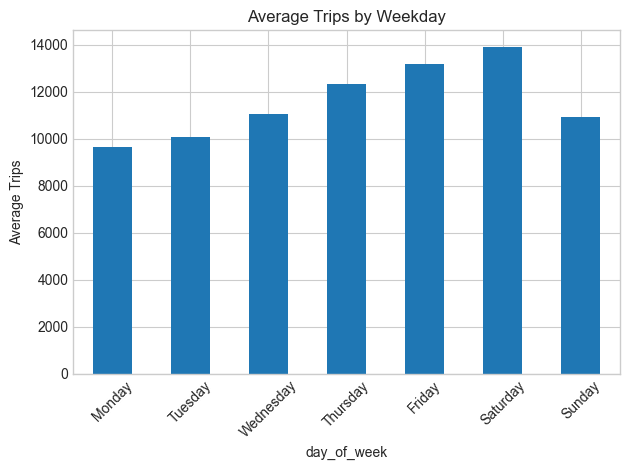

In [14]:
# Weekday patterns
weekday_avg = df.groupby('day_of_week')['trips'].mean().reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
weekday_avg.plot(kind='bar', title='Average Trips by Weekday')
plt.ylabel('Average Trips')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

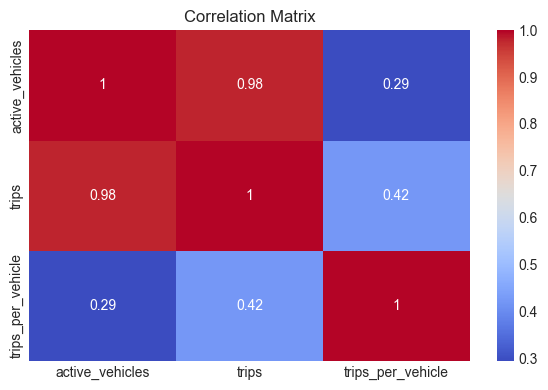

In [15]:
df['trips_per_vehicle'] = df['trips'] / df['active_vehicles']

corr = df[['active_vehicles', 'trips', 'trips_per_vehicle']].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()


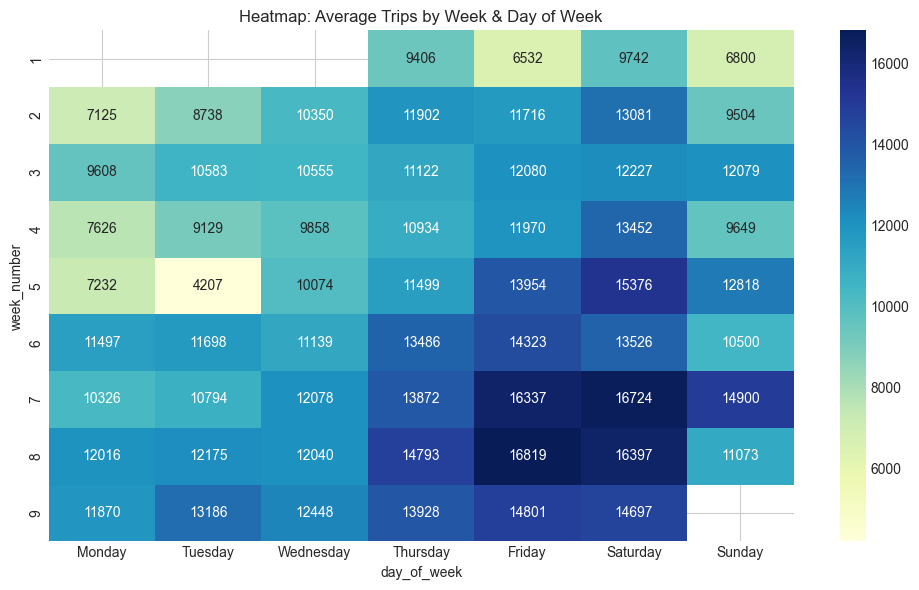

In [16]:
pivot = df.pivot_table(values='trips', index='week_number', columns='day_of_week', aggfunc='mean')
# Reorder columns
ordered_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot = pivot[ordered_days]

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title('Heatmap: Average Trips by Week & Day of Week')
plt.tight_layout()
plt.show()


## Machine Learning 

In [17]:
df_sorted = df.sort_values('date')
trip_lags = df_sorted.groupby('dispatching_base_number')['trips'].shift(1)
df_sorted['trips_lag_1'] = trip_lags

In [18]:
# Drop rows with missing lag features
model_df = df_sorted.dropna()

# Select features
feature_cols = [col for col in model_df.columns if 'lag' in col or 'roll' in col]
X = model_df[feature_cols]
y = model_df['trips']

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=0.2)

In [19]:
from xgboost import XGBRegressor
model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

In [20]:
# Separate features and target
X = df.drop('trips_per_vehicle', axis=1)
y = df['trips_per_vehicle']

In [21]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
X = X.apply(lambda col: le.fit_transform(col) if col.dtype == 'object' else col)

In [22]:
X = X.select_dtypes(exclude=['datetime'])

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)

In [26]:
ensemble_pred = (rf_pred + gb_pred) / 2

## Prediction visualization

In [27]:
from sklearn.metrics import mean_squared_error, r2_score

models = {
    'RandomForest': rf_pred,
    'GBTR': gb_pred,
    'Ensemble': ensemble_pred
}

for name, pred in models.items():
    rmse = mean_squared_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    print(f"{name} → RMSE: {rmse:.2f}, R²: {r2:.2f}")


RandomForest → RMSE: 0.28, R²: 0.84
GBTR → RMSE: 0.16, R²: 0.91
Ensemble → RMSE: 0.20, R²: 0.89


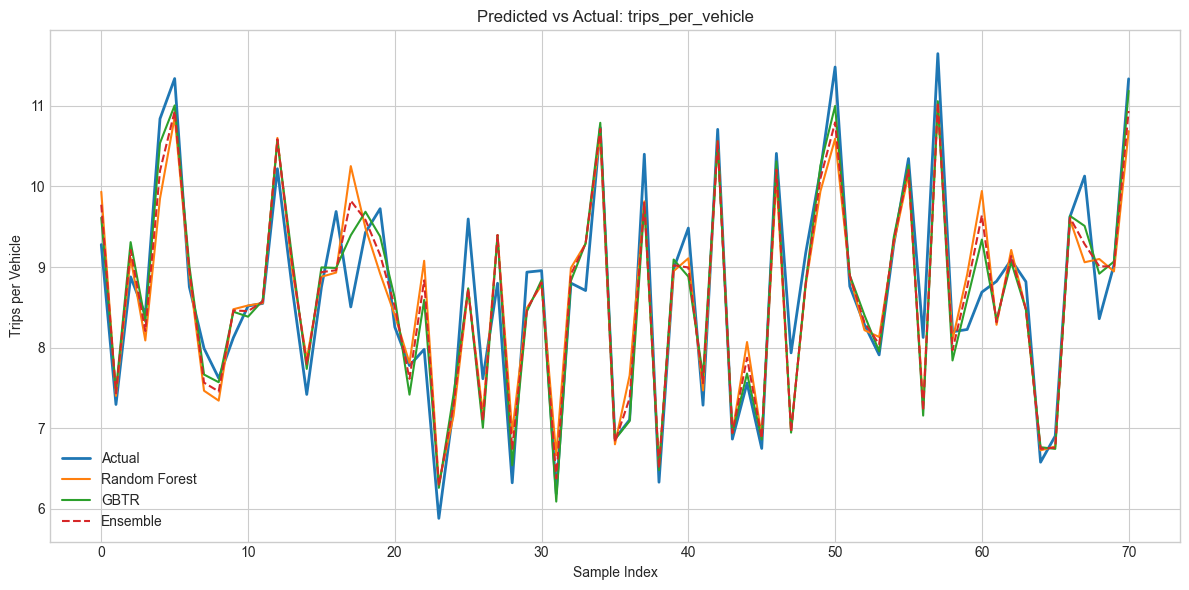

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(y_test.values, label='Actual', linewidth=2)
plt.plot(rf_pred, label='Random Forest')
plt.plot(gb_pred, label='GBTR')
plt.plot(ensemble_pred, label='Ensemble', linestyle='--')
plt.title('Predicted vs Actual: trips_per_vehicle')
plt.xlabel('Sample Index')
plt.ylabel('Trips per Vehicle')
plt.legend()
plt.tight_layout()
plt.show()